In [3]:
import pandas as pd
ablation_incomplete = pd.read_csv("ablation_complete.csv")
ablation_incomplete

,Experiment,Horizon,Model,avg_smape,med_smape,std_smape,avg_rmse,med_rmse,std_rmse
0,all_features,1,DCRNN,26.293264,21.580133,16.694194,0.903362,0.694662,0.782523
1,all_features,1,GraphWaveNet,27.233510,22.815003,16.381411,0.945722,0.745686,0.787838
2,all_features,1,AGCRN,28.817353,24.512293,17.031625,0.968152,0.764223,0.795475
3,all_features,1,GConvLSTM,29.620488,25.033034,16.811595,1.008702,0.804669,0.862525
4,all_features,6,GraphWaveNet,30.618203,25.620409,20.079988,1.008957,0.743306,0.979998
...,...,...,...,...,...,...,...,...,...
103,core_sim25,6,GConvLSTM,31.517631,26.209930,20.870969,1.026843,0.776822,0.977457
104,core_sim25,12,GConvLSTM,37.959969,26.947974,37.523414,1.039792,0.672888,1.215071
105,core_sim25,12,GraphWaveNet,38.194712,28.322184,37.089747,1.050962,0.652229,1.289177
106,core_sim25,12,AGCRN,38.371957,27.709530,37.803695,1.063875,0.706513,1.236623


/var/folders/57/8yr9qn3s45sc5vk_srfp2yv80000gn/T/ipykernel_3284/753809385.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/57/8yr9qn3s45sc5vk_srfp2yv80000gn/T/ipykernel_3284/753809385.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/57/8yr9qn3s45sc5vk_srfp2yv80000gn/T/ipykernel_3284/753809385.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/57/8yr9qn3s45sc5vk_srfp2yv80000gn/T/ipykernel_3284/753809385.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

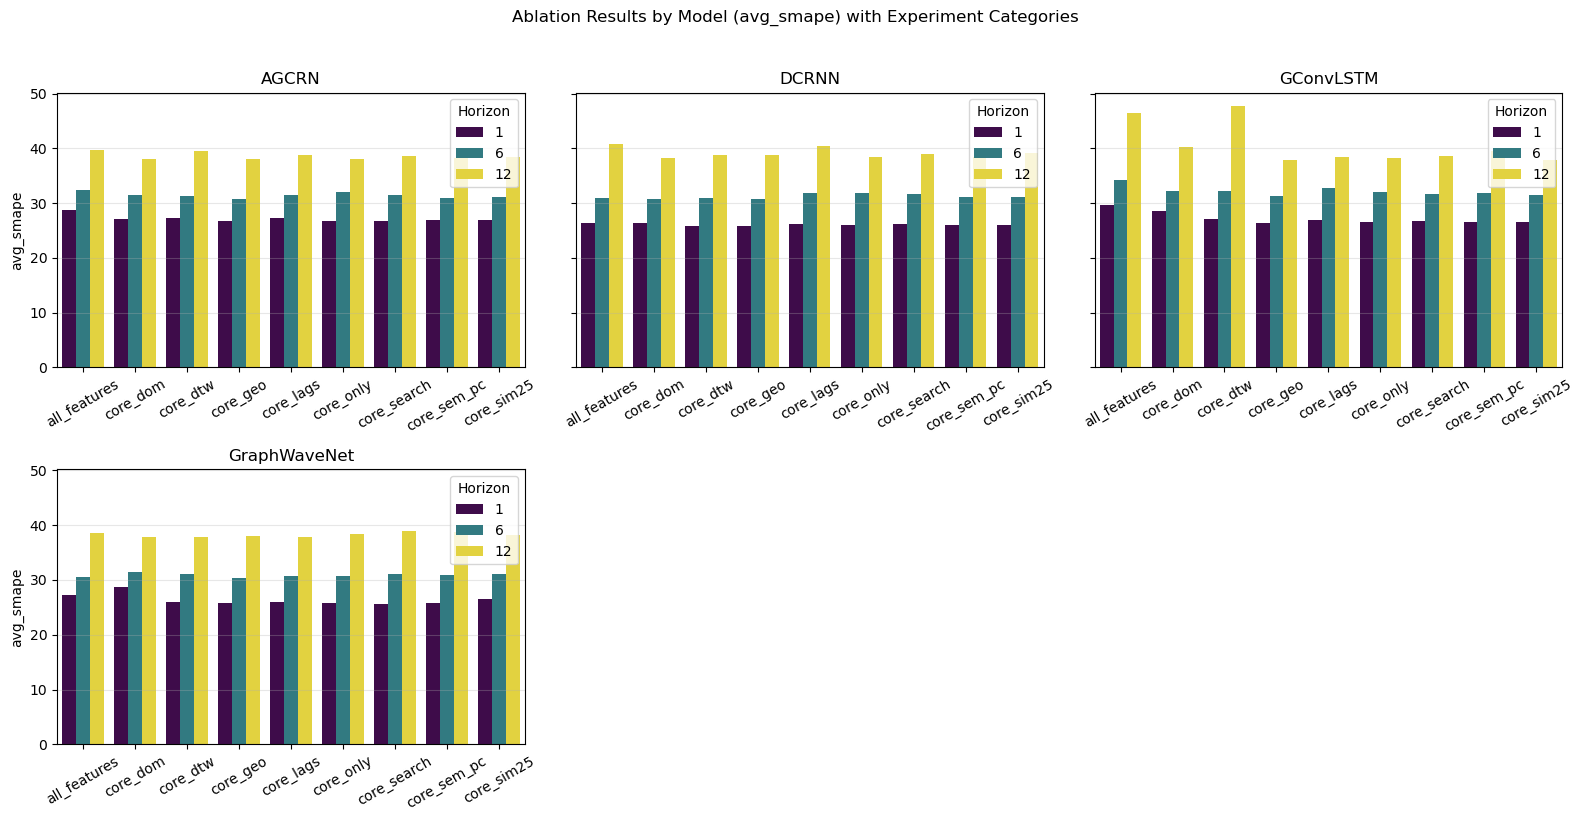

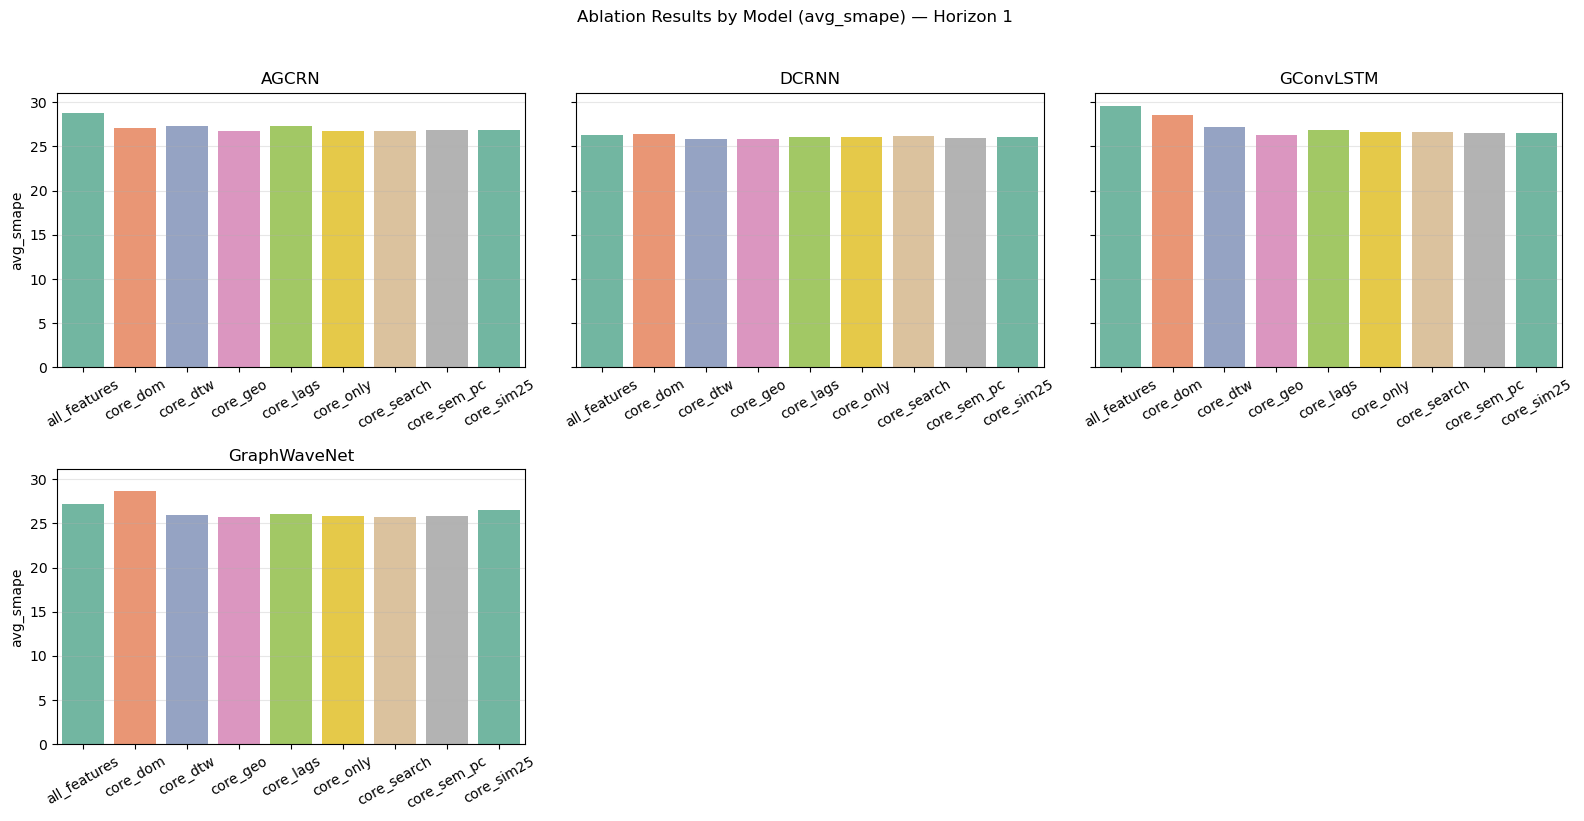

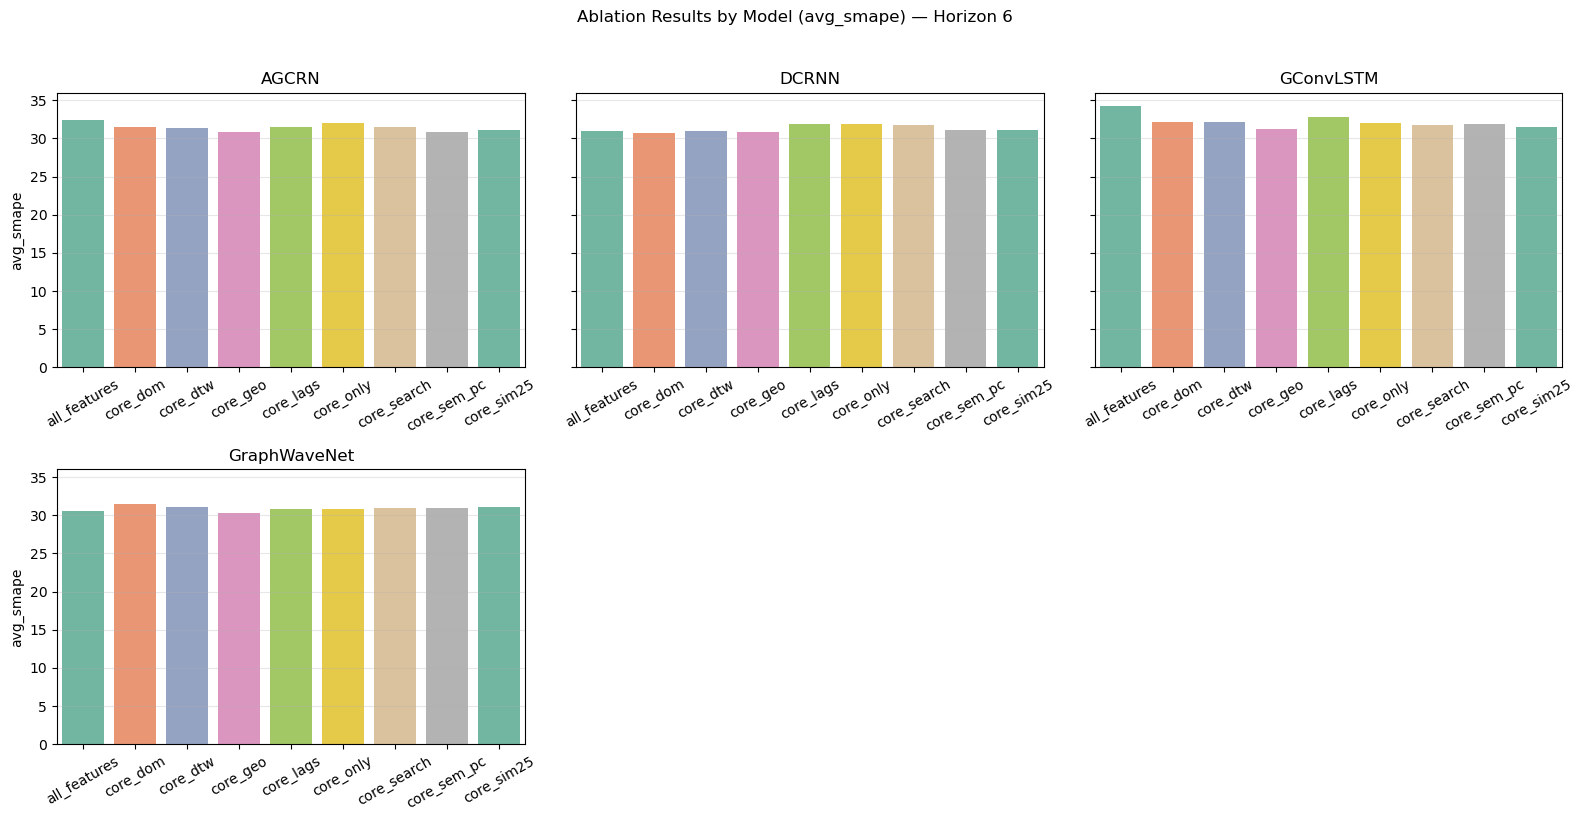

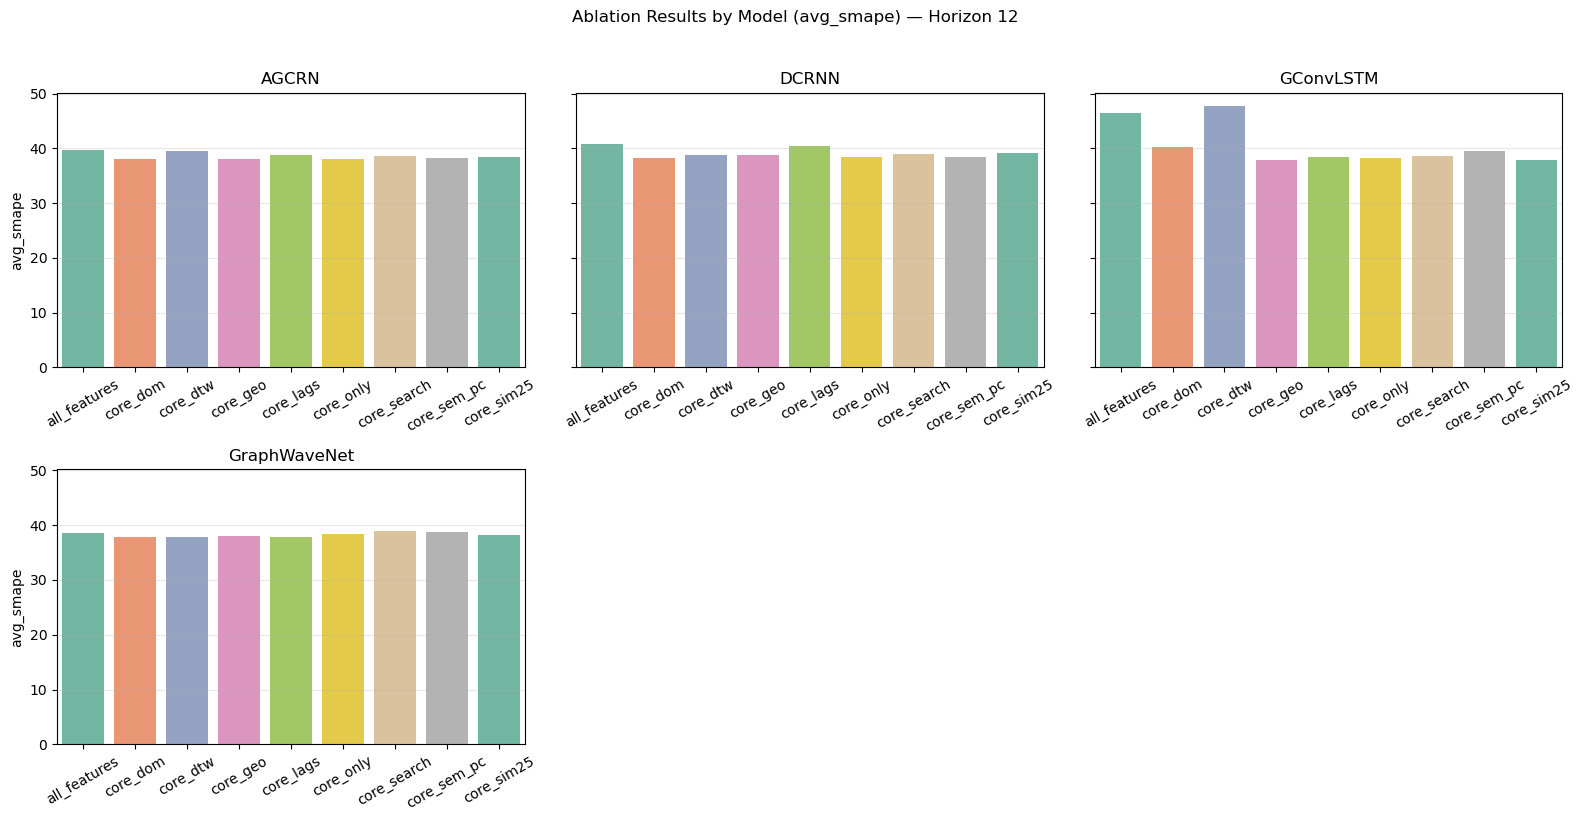

In [4]:
import seaborn as sns

import matplotlib.pyplot as plt

df = ablation_incomplete.copy()
models = sorted(df["Model"].unique())
ncols = 3
nrows = (len(models) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharey=True)
axes = axes.flatten()

palette = sns.color_palette("Set2", df["Experiment"].nunique())

for ax, model in zip(axes, models):
    data = df[df["Model"] == model]
    sns.barplot(
        data=data,
        x="Experiment",
        y="avg_smape",
        hue="Horizon",
        ax=ax,
        palette="viridis",
    )
    ax.set_title(model)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Horizon", loc="upper right")

# Hide unused axes
for ax in axes[len(models):]:
    ax.axis("off")

fig.suptitle("Ablation Results by Model (avg_smape) with Experiment Categories", y=1.02)
fig.tight_layout()
# Separate views by horizon
for horizon in sorted(df["Horizon"].unique()):
    df_h = df[df["Horizon"] == horizon]
    fig_h, axes_h = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharey=True)
    axes_h = axes_h.flatten()

    for ax, model in zip(axes_h, models):
        data_h = df_h[df_h["Model"] == model]
        sns.barplot(
            data=data_h,
            x="Experiment",
            y="avg_smape",
            ax=ax,
            palette="Set2",
        )
        ax.set_title(model)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)
        ax.grid(axis="y", alpha=0.3)

    for ax in axes_h[len(models):]:
        ax.axis("off")

    fig_h.suptitle(f"Ablation Results by Model (avg_smape) — Horizon {horizon}", y=1.02)
    fig_h.tight_layout()

plt.show()